### Buid A basic chat bot with langraph (Graph API)

In [1]:
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages #recducer


In [2]:
class State(TypedDict):
    # Messages have the type "list". The `add_messages` function
    # in the annotation defines how this state key should be updated
    # (in this case, it appends messages to the list, rather than overwriting them)
    
    messages: Annotated[list, add_messages]

graph_builder =StateGraph(State)

In [3]:
graph_builder

In [4]:
import os 
from dotenv import load_dotenv
load_dotenv()
#os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")


True

In [5]:
from langchain_groq import ChatGroq
from langchain.chat_models import init_chat_model

llm = ChatGroq(model="openai/gpt-oss-20b")

In [6]:
# we also do like _>
# llm = init_chat_model("groq:llama-3.1-8b-instant")

In [7]:
# Node functionality 
def chatbot(state):
    return {"messages":[llm.invoke(state["messages"])]}


In [8]:
graph_builder = StateGraph(State)

## Adding node
graph_builder.add_node("llmchatbot",chatbot)

## Adding edges
graph_builder.add_edge(START,"llmchatbot")
graph_builder.add_edge("llmchatbot",END)

## compile the graph
graph = graph_builder.compile()

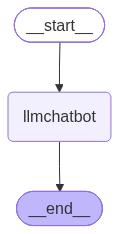

In [9]:
## visulization
from IPython.display import Image,display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except Exception:
    pass


In [10]:
responce=graph.invoke({"messages":"Hi how are you"})

In [11]:
responce["messages"][-1]

AIMessage(content='Hello! I’m doing great—thanks for asking. How about you? How can I help you today?', additional_kwargs={'reasoning_content': 'User: "Hi how are you". They are greeting. We respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 48, 'prompt_tokens': 75, 'total_tokens': 123, 'completion_time': 0.05564144, 'completion_tokens_details': {'reasoning_tokens': 17}, 'prompt_time': 0.003513513, 'prompt_tokens_details': None, 'queue_time': 0.211627186, 'total_time': 0.059154953}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_99996fee8e', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a071a4-4636-7451-9b6c-016d581e9054-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 75, 'output_tokens': 48, 'total_tokens': 123, 'output_token_details': {'reasoning': 17}})

In [12]:
for event in graph.stream({"messages":"hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content)


Hello! I’m doing great—thanks for asking. How can I help you today?


### chat with Tools


In [13]:
from langchain_tavily import TavilySearch

tool = TavilySearch(max_results=2)
tool.invoke("what is langgraph")

{'query': 'what is langgraph',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.ibm.com/think/topics/langgraph',
   'title': 'What is LangGraph?',
   'content': 'LangGraph, created by LangChain, is an open source AI agent framework designed to build, deploy and manage complex generative AI agent workflows. It provides a set of tools and libraries that enable users to create, run and optimize large language models (LLMs) in a scalable and efficient manner. At its core, LangGraph uses the power of graph-based architectures to model and manage the intricate relationships between various components of an AI agent workflow. [...] Agent systems: LangGraph provides a framework for building agent-based systems, which can be used in applications such as robotics, autonomous vehicles or video games.\n\nLLM applications: By using LangGraph’s capabilities, developers can build more sophisticated AI models that learn and improve over time. Norwegian Cr

In [14]:
## custom function 
def multply(a:int,b:int)->int:
    """MUTILPY a and  b 
    Args:
    a (int) : first int
    b (int) : second int
        int: output int 
    """
    return a*b


In [15]:
tools = [tool,multply]

In [16]:
llm_with_tool= llm.bind_tools(tools)

In [17]:
llm_with_tool

_ChatModelBinding(bound=ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002C7E116A660>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002C7E116B0E0>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********')), kwargs={'tools': [{'type': 'function', 'function': {'name': 'tavily_search', 'description': 'A search engine optimized for comprehensive, accurate, and

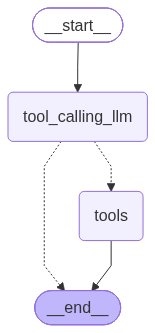

In [18]:
### let's create  state graph 
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node defination
def tool_calling_llm(state):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}
# graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools",END)
## complie the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [19]:
responce=graph.invoke({"messages":"Hi how are you"})

In [20]:
responce["messages"][-1].content

'Hello! I’m doing great—thanks for asking. How can I help you today?'

In [21]:
for event in graph.stream({"messages":"hi how are you"}):
    for value in event.values():
        print(value["messages"][-1].content )

Hi! I'm doing great, thanks for asking. How can I help you today?


In [22]:
for m in responce["messages"]:
    m.pretty_print()

================================ Human Message =================================

Hi how are you
================================== Ai Message ==================================

Hello! I’m doing great—thanks for asking. How can I help you today?


In [23]:
responce = graph.invoke({"messages":"what is 2 multiplied by 7"})
for m in responce["messages"]:
    m.pretty_print()


================================ Human Message =================================

what is 2 multiplied by 7
================================== Ai Message ==================================
Tool Calls:
  multply (fc_d339cea8-01c7-4160-ab01-31dcf065ee7f)
 Call ID: fc_d339cea8-01c7-4160-ab01-31dcf065ee7f
  Args:
    a: 2
    b: 7
================================= Tool Message =================================
Name: multply

14


In [24]:
responce = graph.invoke({"messages":"what is 2 multiplred by 7 and then multilped by 5"})
for m in responce["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is 2 multiplred by 7 and then multilped by 5
================================== Ai Message ==================================

2 multiplied by 7 is 14, and 14 multiplied by 5 equals **70**.


In [25]:
responce = graph.invoke({"messages":"give me the recent ai news  and then multiply 5 * 20"})
for m in responce["messages"]:
    m.pretty_print()

================================ Human Message =================================

give me the recent ai news  and then multiply 5 * 20
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_ca7158b5-63dd-49d4-bcfb-2b427fe6043a)
 Call ID: fc_ca7158b5-63dd-49d4-bcfb-2b427fe6043a
  Args:
    query: recent AI news
    search_depth: basic
    time_range: day
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://www.cnbc.com/video/2026/09/04/recent-ai-hacks-raise-cybersecurity-fears.html", "title": "Recent AI hacks raise cybersecurity fears - CNBC", "content": "Livestream\n\n Make It\n select\n\n USA\n INTL\n\n Livestream\n\n Livestream\n\nWatchlist\n\nSIGN IN\n\nCreate free account\n\nMarkets\n\nBusiness\n\nInvesting\n\nTech\n\nPolitics & Policy\n\nVideo\n\

In [26]:
## so what  tool's answer goes nack to llm and then dicission is taken by llm 
# - Act -> Observe -> Reason

## ReAct agent architecture

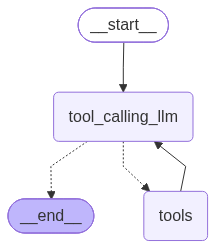

In [27]:
### let's create  state graph 
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition

## Node defination
def tool_calling_llm(state):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}
# graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")
## complie the graph
graph=builder.compile()

display(Image(graph.get_graph().draw_mermaid_png()))

In [28]:
## Now this will answer correctly 
responce = graph.invoke({"messages":"give me the recent ai news  and then multiply 5 * 20"})
for m in responce["messages"]:
    m.pretty_print()

================================ Human Message =================================

give me the recent ai news  and then multiply 5 * 20
================================== Ai Message ==================================
Tool Calls:
  tavily_search (fc_e5d42ccd-4f24-4c0a-9f7d-9be8a1389fbe)
 Call ID: fc_e5d42ccd-4f24-4c0a-9f7d-9be8a1389fbe
  Args:
    query: recent AI news 2026
    search_depth: basic
    topic: news
================================= Tool Message =================================
Name: tavily_search

{"query": "recent AI news 2026", "follow_up_questions": null, "answer": null, "images": [], "results": [{"url": "https://blog.google/innovation-and-ai/technology/google-ai-updates-august-2026", "title": "The latest AI news we announced in August 2026", "content": "Google’s August 2026 updates focus on making artificial intelligence more practical through new hardware like the Pixel 11 series and cost-efficient models like Gemini 3.7 Flash. You can now use enhanced productivity t

## Adding Memoery in Agentic Graph 

In [29]:
responce = graph.invoke({"messages":"hello my name is vishal"})
for m in responce["messages"]:
    m.pretty_print()

================================ Human Message =================================

hello my name is vishal
================================== Ai Message ==================================

Hi Vishal! How can I help you today?


In [30]:
responce = graph.invoke({"messages":"what is my name ?"})
for m in responce["messages"]:
    m.pretty_print()

================================ Human Message =================================

what is my name ?
================================== Ai Message ==================================

I’m not sure what your name is—could you let me know?


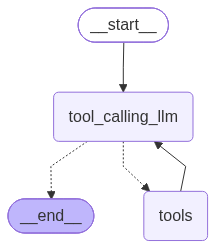

In [31]:
### let's create  state graph 
from langgraph.graph import StateGraph,START,END
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()

## Node defination
def tool_calling_llm(state):
    return {"messages": [llm_with_tool.invoke(state["messages"])]}
# graph 
builder = StateGraph(State)
builder.add_node("tool_calling_llm",tool_calling_llm)
builder.add_node("tools",ToolNode(tools))

## add edges
builder.add_edge(START,"tool_calling_llm")
builder.add_conditional_edges(
    "tool_calling_llm",
    # If the latest message (result) from assistant is a tool call -> tools_condition routes to tools
    # If the latest message (result) from assistant is not a tool call -> tools_condition routes to END
    tools_condition
)
builder.add_edge("tools","tool_calling_llm")
## complie the graph
graph=builder.compile(checkpointer=memory)

display(Image(graph.get_graph().draw_mermaid_png()))

In [32]:
config = {"configurable":{"thread_id":"1"}}
responce = graph.invoke({"messages":"hi my name is vishal "},config=config)
responce

{'messages': [HumanMessage(content='hi my name is vishal ', additional_kwargs={}, response_metadata={}, id='1a696547-88e6-4c62-8bea-aa5fa508484c'),
  AIMessage(content='Hello Vishal! How can I help you today?', additional_kwargs={'reasoning_content': 'User says: "hi my name is vishal". Probably they want greeting. No question. We respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 375, 'total_tokens': 420, 'completion_time': 0.05075737, 'completion_tokens_details': {'reasoning_tokens': 25}, 'prompt_time': 0.020804991, 'prompt_tokens_details': None, 'queue_time': 0.247532143, 'total_time': 0.071562361}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_5979a0e1b7', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a071a4-81b4-7210-aaa6-c91dbc44a43e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 375, 'output_tokens': 45, 'total_tokens': 420, 

In [33]:
responce["messages"][-1].content

'Hello Vishal! How can I help you today?'

In [34]:
responce = graph.invoke({"messages":"what is my name..?"},config=config)
responce



{'messages': [HumanMessage(content='hi my name is vishal ', additional_kwargs={}, response_metadata={}, id='1a696547-88e6-4c62-8bea-aa5fa508484c'),
  AIMessage(content='Hello Vishal! How can I help you today?', additional_kwargs={'reasoning_content': 'User says: "hi my name is vishal". Probably they want greeting. No question. We respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 45, 'prompt_tokens': 375, 'total_tokens': 420, 'completion_time': 0.05075737, 'completion_tokens_details': {'reasoning_tokens': 25}, 'prompt_time': 0.020804991, 'prompt_tokens_details': None, 'queue_time': 0.247532143, 'total_time': 0.071562361}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_5979a0e1b7', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a071a4-81b4-7210-aaa6-c91dbc44a43e-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 375, 'output_tokens': 45, 'total_tokens': 420, 

In [35]:
responce["messages"][-1].content

'Your name is Vishal.'

# Streaming 

In [36]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()


In [37]:
def superBot(State: State):
    return {"messages": [llm.invoke(State["messages"])]}

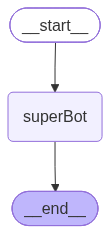

In [38]:
graph= StateGraph(State)

## Node 
graph.add_node("superBot",superBot)

## Edges
graph.add_edge(START,"superBot")
graph.add_edge("superBot",END)

graph_builder = graph.compile(checkpointer=memory)

## Display 
from IPython.display import Image,display
display(Image(graph_builder.get_graph().draw_mermaid_png()))

In [39]:
config = {"configurable":{"thread_id":"1"}}
responce = graph_builder.invoke({"messages":"hi name is vishal i like poetry"},config)

In [40]:
responce["messages"][-1].content

'Hello Vishal! 👋  \nIt’s great to meet someone who enjoys poetry.  \n\nWould you like me to write a short poem for you right now?  \nIf so, let me know:  \n- Any particular theme or mood you’re in the mood for?  \n- Do you have a favorite poet or style you admire?  \n\nOr if you just want to chat about poetry, feel free to share!'

## Streaming

**Methods:** `.stream()` and `.astream()`

- These methods are sync and async methods for streaming back results.

### Additional parameters in streaming modes for graph state

- **`values`**: This streams the full state of the graph after each node is called.
- **`updates`**: This streams updates to the state of the graph after each node is called.

In [41]:
config = {"configurable":{"thread_id":"3"}}

for chunk in graph_builder.stream({"messages":"hi my name is vishal i like poetries"},config,stream_mode="updates"):
    print(chunk)

{'superBot': {'messages': [AIMessage(content='Hello Vishal! 👋 It’s great to meet someone who loves poetry. Do you have a favorite poem or poet that you enjoy? Or maybe you’d like me to craft a quick poem just for you? Let me know what you’re in the mood for!', additional_kwargs={'reasoning_content': 'The user says: "hi my name is vishal i like poetries". They want to talk about poetry? The user hasn\'t asked a question but perhaps expects a response. We should greet them, acknowledge their name, and ask if they\'d like to read or write poetry, or share their favorite poems. We can also offer to write a poem. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 140, 'prompt_tokens': 83, 'total_tokens': 223, 'completion_time': 0.145127465, 'completion_tokens_details': {'reasoning_tokens': 77}, 'prompt_time': 0.005586825, 'prompt_tokens_details': None, 'queue_time': 0.26476656, 'total_time': 0.15071429}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 

In [42]:
for chunk in graph_builder.stream({"messsages":"hi my name is vishal i like poetries"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='hi my name is vishal i like poetries', additional_kwargs={}, response_metadata={}, id='336dd075-ee29-45f7-82a6-28cc8ffe082c'), AIMessage(content='Hello Vishal! 👋 It’s great to meet someone who loves poetry. Do you have a favorite poem or poet that you enjoy? Or maybe you’d like me to craft a quick poem just for you? Let me know what you’re in the mood for!', additional_kwargs={'reasoning_content': 'The user says: "hi my name is vishal i like poetries". They want to talk about poetry? The user hasn\'t asked a question but perhaps expects a response. We should greet them, acknowledge their name, and ask if they\'d like to read or write poetry, or share their favorite poems. We can also offer to write a poem. So respond friendly.'}, response_metadata={'token_usage': {'completion_tokens': 140, 'prompt_tokens': 83, 'total_tokens': 223, 'completion_time': 0.145127465, 'completion_tokens_details': {'reasoning_tokens': 77}, 'prompt_time': 0.005586825, 'promp

In [43]:
config = {"configurable":{"thread_id":"4"}}

for chunk in graph_builder.stream({"messages":"hi my name is vishal i like poetries"},config,stream_mode="updates"):
    print(chunk)

{'superBot': {'messages': [AIMessage(content='Hi Vishal! 🎉  \nI’d love to share a little poem with you:\n\n> **Whispers of the Dawn**  \n>   \n> The first light slips through curtains,  \n>  A hush that paints the sky in gold.  \n>  Morning breathes a quiet promise,  \n>  While shadows lift, brave and bold.  \n>   \n> Each feathered breeze, a secret song,  \n>  A gentle nod to day’s new start.  \n>  In every breath, a world reborn—  \n>  And hope, like fire, fills the heart.\n\nWhat kind of poetry do you enjoy?  \n- Classic sonnets or free verse?  \n- Romantic, nature‑focused, or something more experimental?  \n- Any favorite poets or themes you’d like me to draw inspiration from?\n\nLet me know, and I can craft something that feels just right for you!', additional_kwargs={'reasoning_content': 'User says: "hi my name is vishal i like poetries". They want presumably poetry. The user hasn\'t asked a specific question. We need to respond. We should ask clarifying question or provide a sho

In [44]:
for chunk in graph_builder.stream({"messages":"i also like sketching"},config,stream_mode="values"):
    print(chunk)

{'messages': [HumanMessage(content='hi my name is vishal i like poetries', additional_kwargs={}, response_metadata={}, id='ad12a6ff-ae44-4074-908f-ffc2c68c070e'), AIMessage(content='Hi Vishal! 🎉  \nI’d love to share a little poem with you:\n\n> **Whispers of the Dawn**  \n>   \n> The first light slips through curtains,  \n>  A hush that paints the sky in gold.  \n>  Morning breathes a quiet promise,  \n>  While shadows lift, brave and bold.  \n>   \n> Each feathered breeze, a secret song,  \n>  A gentle nod to day’s new start.  \n>  In every breath, a world reborn—  \n>  And hope, like fire, fills the heart.\n\nWhat kind of poetry do you enjoy?  \n- Classic sonnets or free verse?  \n- Romantic, nature‑focused, or something more experimental?  \n- Any favorite poets or themes you’d like me to draw inspiration from?\n\nLet me know, and I can craft something that feels just right for you!', additional_kwargs={'reasoning_content': 'User says: "hi my name is vishal i like poetries". They wa

In [45]:
config = {"configurable":{"thread_id":"5"}}

async for  event in graph_builder.astream_events({"messages":"hi my name is vishal i like poetries"},config,version="v2",):
    print(event)

{'event': 'on_chain_start', 'data': {'input': {'messages': 'hi my name is vishal i like poetries'}}, 'name': 'LangGraph', 'tags': [], 'run_id': '01a071a4-9a5a-7410-8a1b-937580606f76', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph'}, 'parent_ids': []}
{'event': 'on_chain_start', 'data': {'input': {'messages': [HumanMessage(content='hi my name is vishal i like poetries', additional_kwargs={}, response_metadata={}, id='20b9a591-6a50-4162-807a-090d0487e212')]}}, 'name': 'superBot', 'tags': ['graph:step:1'], 'run_id': '01a071a4-9a5f-7dc1-9832-ad13623c84e6', 'metadata': {'thread_id': '5', 'ls_integration': 'langgraph', 'langgraph_step': 1, 'langgraph_node': 'superBot', 'langgraph_triggers': ('branch:to:superBot',), 'langgraph_path': ('__pregel_pull', 'superBot'), 'langgraph_checkpoint_ns': 'superBot:4febd79e-e517-6e6c-90d1-b4791bde1c5c'}, 'parent_ids': ['01a071a4-9a5a-7410-8a1b-937580606f76']}
{'event': 'on_chat_model_start', 'data': {'input': {'messages': [[HumanMessage(conten

# Human in the loop 

In [48]:
import os 
from langchain.chat_models import init_chat_model
llm = init_chat_model("groq:openai/gpt-oss-20b")
llm

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.1', 'langchain': '1.3.18'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000002C7E3083C50>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002C7E31BC690>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

In [56]:
from asyncio import graph
from typing import Annotated

from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing_extensions import TypedDict

from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode,tools_condition

from langgraph.types import Command,interrupt

class State(TypedDict):
    messages: Annotated[list, add_messages]

graph_builder = StateGraph(State)

@tool
def human_asistance (query:str)->str:
    """request asistance from human"""
    human_responce = interrupt({"query":query})
    return human_responce["data"]

tool = TavilySearch(max_results=2)
tools =[tool,human_asistance]
llm_with_tool = llm.bind_tools(tools)

def chatbot(State:State):
    message =llm_with_tool.invoke(State["messages"])
    # we will be interupting during tool execution 
    # we disable prallel tools calling to avoid  repeating any 
    # tool inovocation when we resume
    return {"messages":[message]}

graph_builder.add_node("chatbot",chatbot)
tool_Node = ToolNode(tools=tools)
graph_builder.add_node("tools",tool_Node)

graph_builder.add_conditional_edges(
    "chatbot",
    tools_condition,
)

graph_builder.add_edge("tools","chatbot")
graph_builder.add_edge(START,"chatbot")


In [57]:
memory=MemorySaver()
graph = graph_builder.compile(checkpointer=memory)

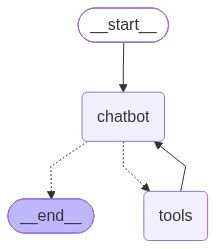

In [58]:
from IPython.display import Image,display


display(Image(graph.get_graph().draw_mermaid_png()))


In [ ]:
user_input = "I need some expert guidance for building an AI agent. Could you request assistance for me?"

config = {
    "configurable": {
        "thread_id": "1"
    }
}

events = graph.stream(
    {"messages": [("user", user_input)]},
    config,
    stream_mode="values"
)

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print() 

================================ Human Message =================================

I need some expert guidance for building an AI agent. Could you request assistance for me?
================================== Ai Message ==================================
Tool Calls:
  human_asistance (fc_6a1f12d0-3989-4eb5-8b4e-71ccab438772)
 Call ID: fc_6a1f12d0-3989-4eb5-8b4e-71ccab438772
  Args:
    query: I need some expert guidance for building an AI agent.
================================== Ai Message ==================================
Tool Calls:
  human_asistance (fc_6a1f12d0-3989-4eb5-8b4e-71ccab438772)
 Call ID: fc_6a1f12d0-3989-4eb5-8b4e-71ccab438772
  Args:
    query: I need some expert guidance for building an AI agent.


In [62]:
human_response = (
    "We, the experts are here to help! We'd recommend you check out LangGraph to build your agent."
    " It's much more reliable and extensible than simple autonomous agents."
)

human_command = Command(resume={"data": human_response})

events = graph.stream(human_command, config, stream_mode="values")

for event in events:
    if "messages" in event:
        event["messages"][-1].pretty_print()

================================== Ai Message ==================================
Tool Calls:
  human_asistance (fc_6a1f12d0-3989-4eb5-8b4e-71ccab438772)
 Call ID: fc_6a1f12d0-3989-4eb5-8b4e-71ccab438772
  Args:
    query: I need some expert guidance for building an AI agent.
================================= Tool Message =================================
Name: human_asistance

We, the experts are here to help! We'd recommend you check out LangGraph to build your agent. It's much more reliable and extensible than simple autonomous agents.
================================== Ai Message ==================================

Absolutely! Here’s a practical, step‑by‑step blueprint for building a robust AI agent, plus a curated list of tools, best practices, and resources to get you started quickly.

---

## 1. Clarify the Agent’s Purpose

| Question | Why it matters |
|----------|----------------|
| **What problem is the agent solving?** | Defines scope, success metrics, and data needs. |
| **W